In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv("hypertension_dataset.csv")

In [6]:
df.head(5)

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [7]:
df.shape

(1985, 11)

In [8]:
df.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration',
       'BMI', 'Medication', 'Family_History', 'Exercise_Level',
       'Smoking_Status', 'Has_Hypertension'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB


In [10]:
df.isnull().sum()

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

In [11]:
# Remove Missing Values
df.dropna()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No
5,20,10.8,3,Hypertension,5.2,21.9,Beta Blocker,Yes,High,Non-Smoker,Yes
6,39,8.9,0,Normal,7.8,27.6,Beta Blocker,Yes,High,Non-Smoker,No
8,19,9.3,7,Normal,4.7,36.5,Beta Blocker,Yes,Low,Smoker,Yes
...,...,...,...,...,...,...,...,...,...,...,...
1976,68,12.5,9,Hypertension,6.3,26.7,Other,No,Moderate,Non-Smoker,Yes
1977,63,6.8,9,Normal,6.5,24.5,Beta Blocker,Yes,Low,Non-Smoker,Yes
1979,49,8.2,10,Prehypertension,8.1,29.0,Diuretic,No,Low,Smoker,No
1980,56,10.2,0,Normal,6.5,25.0,Diuretic,Yes,Low,Non-Smoker,Yes


In [12]:
df.shape

(1985, 11)

In [13]:
# Encode Categorical Data
df = pd.get_dummies(df, drop_first=True)

In [14]:
df.columns

Index(['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI',
       'BP_History_Normal', 'BP_History_Prehypertension',
       'Medication_Beta Blocker', 'Medication_Diuretic', 'Medication_Other',
       'Family_History_Yes', 'Exercise_Level_Low', 'Exercise_Level_Moderate',
       'Smoking_Status_Smoker', 'Has_Hypertension_Yes'],
      dtype='object')

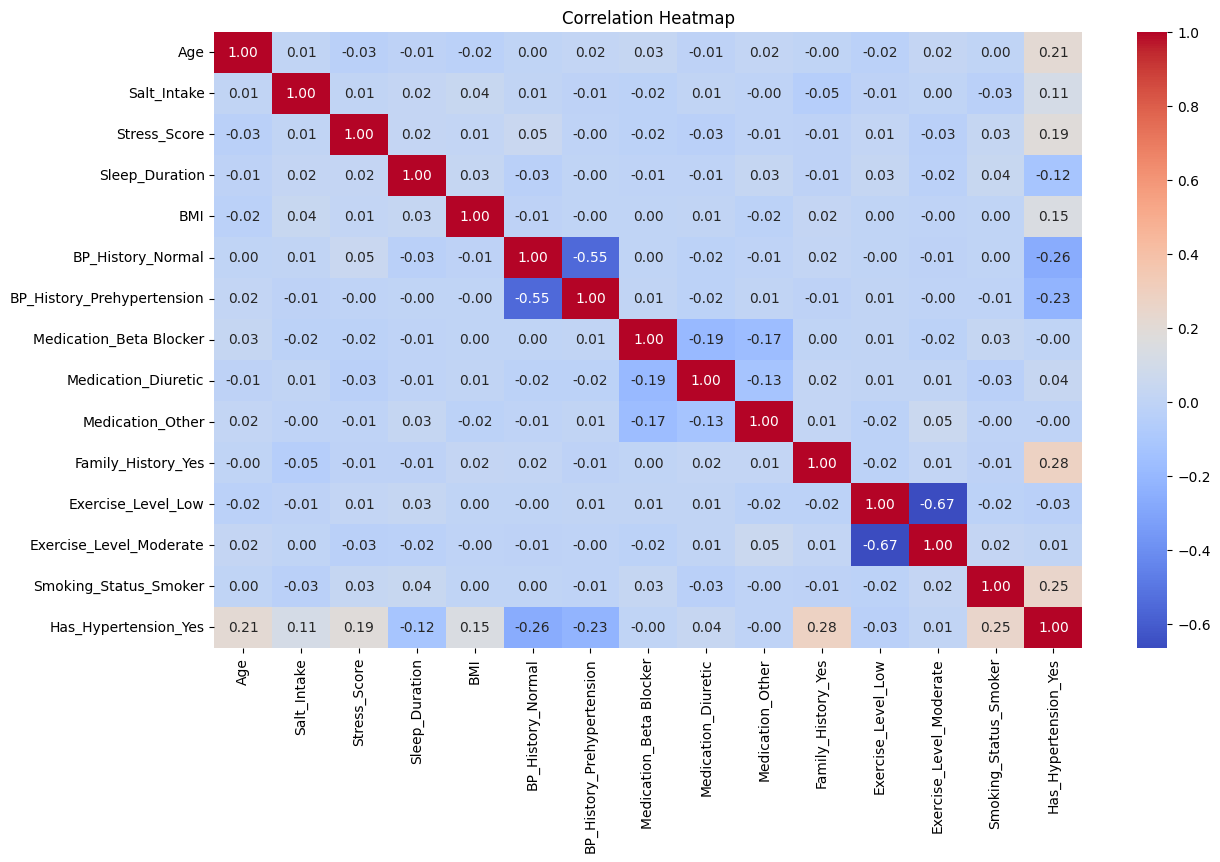

In [15]:
# Correlation Heatmap
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# Define Features and Target
# Target column after get_dummies likely becomes Has_Hypertension_Yes

x = df.drop("Has_Hypertension_Yes", axis=1)
y = df["Has_Hypertension_Yes"]

In [18]:
x.shape

(1985, 14)

In [19]:
y.shape

(1985,)

In [20]:
# Split Dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
x_train.shape

(1588, 14)

In [22]:
y_train.shape

(1588,)

In [23]:
x_test.shape

(397, 14)

In [24]:
y_test.shape

(397,)

In [25]:
# Feature Scaling
# Scaling sirf X par hoti hai, y par nahi

sc = StandardScaler()

In [27]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
# Train Model

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)


# Internally model ek mathematical box (black box) banata hai
# Is box ke andar hota hai:
# Data patterns (relationships)
# Weights / parameters
# Rules jo model ne seekhe

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
# Prediction
y_pred = rf.predict(x_test)

In [ ]:
# Model Evaluation
accuracy_score(y_test, y_pred)    

Accuracy Score:  

0.9420654911838791

In [ ]:
classification_report(y_test, y_pred)   

'              precision    recall  f1-score   support\n\n       False       0.94      0.94      0.94       192\n        True       0.94      0.95      0.94       205\n\n    accuracy                           0.94       397\n   macro avg       0.94      0.94      0.94       397\nweighted avg       0.94      0.94      0.94       397\n'

In [40]:
cm = confusion_matrix(y_test, y_pred)

In [41]:
cm

array([[180,  12],
       [ 11, 194]])

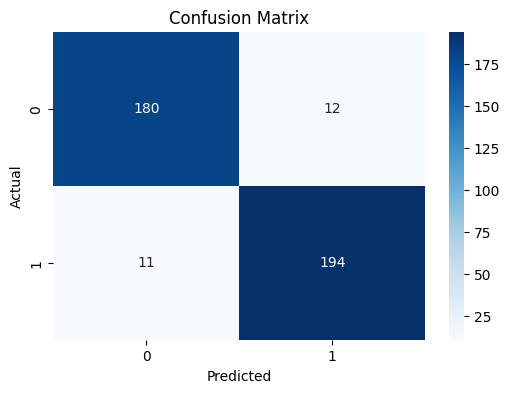

In [43]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

# annot=True   ->  Har box ke andar number likh deta hai

# fmt="d"  ->   
# Format = integer (count values)
# ✔️ Confusion matrix me:
# 10, 25, 50 jaise numbers hote hain
# 👉 isliye "d" (decimal integer)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

In [48]:
feature_importance

,Feature,Importance
0,Age,0.131516
6,BP_History_Prehypertension,0.125015
5,BP_History_Normal,0.122415
4,BMI,0.114952
3,Sleep_Duration,0.106558
2,Stress_Score,0.103706
1,Salt_Intake,0.103667
10,Family_History_Yes,0.075494
13,Smoking_Status_Smoker,0.064017
7,Medication_Beta Blocker,0.012042


In [51]:
# New Data Prediction

# Example values
# In new_data, columns must match original feature columns

new_data = pd.DataFrame([{
    "Age": 45,
    "BMI": 28,
    "Salt_Intake": 8,
    "Stress_Score": 7,
    "Sleep_Hours": 5,
    "Heart_Rate": 80,
    "Cholesterol": 190,
    "Exercise_Hours": 2
}])

In [55]:
# Convert new_data into same encoded format as training data
new_data = pd.get_dummies(new_data)

In [57]:
# Match training columns
new_data = new_data.reindex(columns=x.columns, fill_value=0)

In [58]:
# Scale new data
new_data_scaled = sc.transform(new_data)

In [60]:
# Predict
prediction = rf.predict(new_data_scaled)

In [61]:
prediction

array([ True])

In [63]:
if(prediction[0] == 1):
    print("Patient has Hypertension")
else:
    print("Patient does not have Hypertension")

Patient has Hypertension


# New Data

In [65]:
new_data = pd.DataFrame([{
    "Age": 60,
    "BMI": 32,
    "Salt_Intake": 10,
    "Stress_Score": 9,
    "Sleep_Hours": 4,
    "Heart_Rate": 95,
    "Cholesterol": 240,
    "Exercise_Hours": 0
}])

In [66]:
rf.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
